<a href="https://colab.research.google.com/github/07Akshaya/Statistical-Learning-e22019/blob/main/Assignment_6_e22019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colab usually ships these; uncomment if a package is missing.
# !pip -q install kagglehub scikit-learn seaborn statsmodels

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

# Part 1 — Gaussian Process Regression

The Energy Efficiency dataset (768 buildings simulated in Ecotect) has 8 features `X1`–`X8` and two responses: `Y1` (**Heating Load**) and `Y2` (**Cooling Load**).

**What does "model both loads as a *single-parameter* GP" mean?**
A naïve approach fits *two* independent GPs, one per load. But heating and cooling load are driven by the same building geometry and are physically coupled, so they are expected to be very strongly correlated. If almost all of their joint variance lies along **one** direction, the two responses can be collapsed into a **single latent load parameter** and predicted with **one** GP, then mapped back to both loads. We test exactly that:

1. Quantify the `Y1`–`Y2` correlation.
2. Reduce `(Y1, Y2)` to a single parameter `Z` = first principal component.
3. Fit **one** GP: `X → Z`, reconstruct both loads, evaluate.
4. Compare against the two-independent-GP baseline to measure the accuracy cost.

In [2]:
import kagglehub
path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")
print("Dataset path:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Dataset path: /kaggle/input/eergy-efficiency-dataset
Files: ['ENB2012_data.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "ENB2012_data.csv"))

# Normalise column names: some copies ship descriptive headers, others X1..Y2.
canonical = ["X1","X2","X3","X4","X5","X6","X7","X8","Y1","Y2"]
if list(df.columns[:10]) != canonical:
    df = df.iloc[:, :10]
    df.columns = canonical

feature_label = {
    "X1":"Relative Compactness","X2":"Surface Area","X3":"Wall Area",
    "X4":"Roof Area","X5":"Overall Height","X6":"Orientation",
    "X7":"Glazing Area","X8":"Glazing Area Distribution",
    "Y1":"Heating Load","Y2":"Cooling Load",
}
df = df.dropna().reset_index(drop=True)
print("Shape:", df.shape)
df.head()

Shape: (768, 10)


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


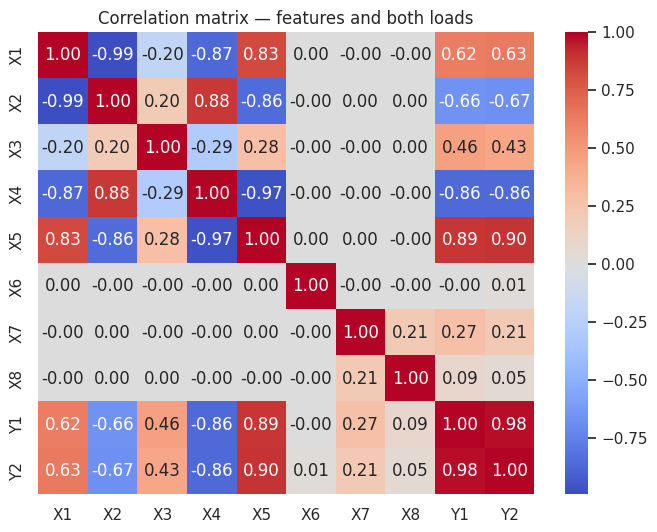

Pearson r between Heating Load (Y1) and Cooling Load (Y2): 0.9759


In [4]:
# --- EDA: correlation structure ---
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix — features and both loads")
plt.show()

r = np.corrcoef(df["Y1"], df["Y2"])[0,1]
print(f"Pearson r between Heating Load (Y1) and Cooling Load (Y2): {r:.4f}")

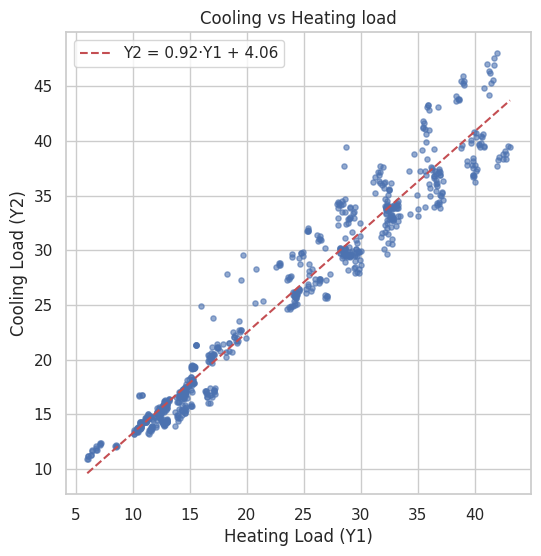

In [5]:
# Cooling vs Heating load — visual check of near-linear coupling
y1, y2 = df["Y1"].values, df["Y2"].values
m, b = np.polyfit(y1, y2, 1)
xs = np.linspace(y1.min(), y1.max(), 100)

plt.figure(figsize=(6,6))
plt.scatter(y1, y2, s=14, alpha=0.6)
plt.plot(xs, m*xs + b, "r--", label=f"Y2 = {m:.2f}·Y1 + {b:.2f}")
plt.xlabel("Heating Load (Y1)"); plt.ylabel("Cooling Load (Y2)")
plt.title("Cooling vs Heating load"); plt.legend(); plt.show()

Collapsing the two loads into one parameter
We standardise (Y1, Y2) and take their first principal component Z. The PCA explained-variance ratio tells us how much of the joint behaviour a single parameter can carry. If PC1 ≈ 1, a single-parameter GP is well justified.

In [6]:
Y = df[["Y1","Y2"]].values
y_scaler = StandardScaler().fit(Y)
Y_std = y_scaler.transform(Y)

pca = PCA(n_components=2).fit(Y_std)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print(f"PC1 carries {pca.explained_variance_ratio_[0]*100:.2f}% of the joint variance.")
print("PC1 loadings on (Y1, Y2):", np.round(pca.components_[0], 3))

Z = pca.transform(Y_std)[:, 0]          # the single latent load parameter

Explained variance ratio: [0.9879 0.0121]
PC1 carries 98.79% of the joint variance.
PC1 loadings on (Y1, Y2): [0.707 0.707]


In [7]:
# --- Train/test split (keep indices so we can recover the true loads) ---
features = ["X1","X2","X3","X4","X5","X6","X7","X8"]
X = df[features].values
idx = np.arange(len(df))

X_train, X_test, z_train, z_test, idx_train, idx_test = train_test_split(
    X, Z, idx, test_size=0.2, random_state=RANDOM_STATE)

x_scaler = StandardScaler().fit(X_train)
X_train_s = x_scaler.transform(X_train)
X_test_s  = x_scaler.transform(X_test)

In [8]:
# --- The single-parameter GP:  X -> Z ---
# ARD RBF (one length-scale per feature) lets the GP learn feature relevance.
def make_kernel(d):
    return (C(1.0, (1e-2, 1e2))
            * RBF(length_scale=np.ones(d), length_scale_bounds=(1e-2, 1e3))
            + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-5, 1e1)))

gp = GaussianProcessRegressor(kernel=make_kernel(X.shape[1]),
                              normalize_y=True, n_restarts_optimizer=4,
                              random_state=RANDOM_STATE)
gp.fit(X_train_s, z_train)
print("Learned kernel:\n", gp.kernel_)

z_pred, z_std = gp.predict(X_test_s, return_std=True)
print(f"\nR^2 on the latent parameter Z (test): {r2_score(z_test, z_pred):.4f}")

Learned kernel:
 1.13**2 * RBF(length_scale=[1e+03, 1e+03, 0.851, 0.962, 1.53, 2.37, 9.33, 1.25]) + WhiteKernel(noise_level=0.00141)

R^2 on the latent parameter Z (test): 0.9969


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [9]:
# --- Map the predicted single parameter back to both loads ---
# Reconstruct standardised (Y1, Y2) from PC1 only (PC2 fixed at its mean = 0).
Z_full = np.column_stack([z_pred, np.zeros_like(z_pred)])
Y_hat = y_scaler.inverse_transform(pca.inverse_transform(Z_full))
Y_true = df[["Y1","Y2"]].values[idx_test]

single_param = {}
for j, name in enumerate(["Heating Load (Y1)", "Cooling Load (Y2)"]):
    r2   = r2_score(Y_true[:, j], Y_hat[:, j])
    rmse = np.sqrt(mean_squared_error(Y_true[:, j], Y_hat[:, j]))
    single_param[name] = (r2, rmse)
    print(f"Single-parameter GP  ->  {name}:  R^2={r2:.4f}  RMSE={rmse:.3f}")

Single-parameter GP  ->  Heating Load (Y1):  R^2=0.9869  RMSE=1.168
Single-parameter GP  ->  Cooling Load (Y2):  R^2=0.9809  RMSE=1.330


In [10]:
# --- Baseline: two independent GPs (one per load) ---
def fit_gp(y):
    g = GaussianProcessRegressor(kernel=make_kernel(X.shape[1]), normalize_y=True,
                                 n_restarts_optimizer=4, random_state=RANDOM_STATE)
    return g.fit(X_train_s, y)

independent = {}
for j, name in enumerate(["Heating Load (Y1)", "Cooling Load (Y2)"]):
    y_tr = df[["Y1","Y2"]].values[idx_train][:, j]
    y_te = Y_true[:, j]
    g = fit_gp(y_tr)
    yp = g.predict(X_test_s)
    independent[name] = (r2_score(y_te, yp), np.sqrt(mean_squared_error(y_te, yp)))
    print(f"Independent GP       ->  {name}:  R^2={independent[name][0]:.4f}  "
          f"RMSE={independent[name][1]:.3f}")

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 5 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Independent GP       ->  Heating Load (Y1):  R^2=0.9978  RMSE=0.479
Independent GP       ->  Cooling Load (Y2):  R^2=0.9958  RMSE=0.626


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 3 of parameter k1__k2__length_scale is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


In [11]:
# --- Side-by-side comparison table ---
rows = []
for name in single_param:
    rows.append([name, *single_param[name], *independent[name]])
comp = pd.DataFrame(rows, columns=["Load",
        "R2 (single-param GP)","RMSE (single-param GP)",
        "R2 (independent GP)","RMSE (independent GP)"]).set_index("Load")
comp.round(4)

,R2 (single-param GP),RMSE (single-param GP),R2 (independent GP),RMSE (independent GP)
Load,,,,
Heating Load (Y1),0.9869,1.1683,0.9978,0.4789
Cooling Load (Y2),0.9809,1.3300,0.9958,0.6259


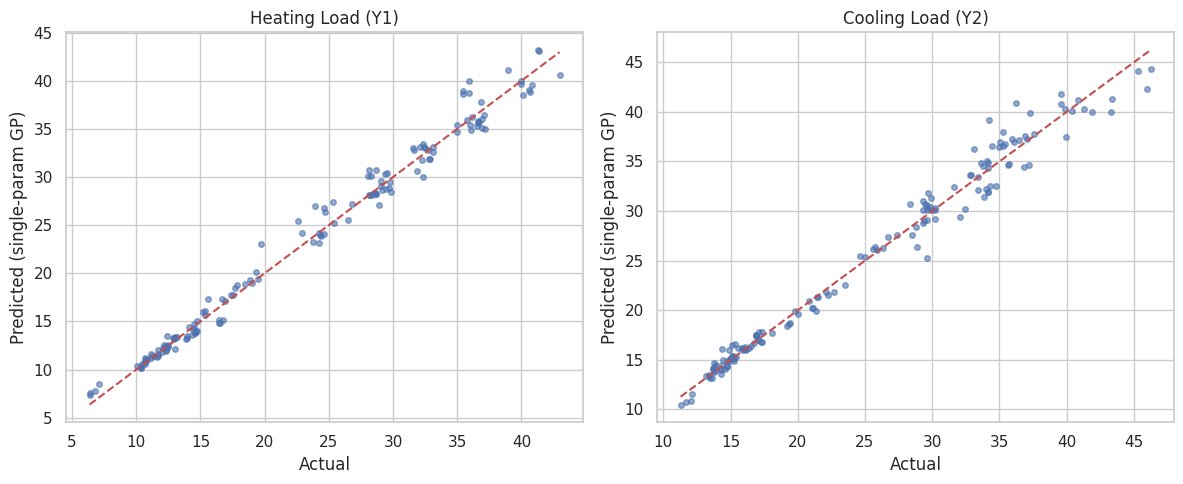

In [12]:
# --- Predicted vs actual for the single-parameter GP ---
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for j, name in enumerate(["Heating Load (Y1)", "Cooling Load (Y2)"]):
    ax[j].scatter(Y_true[:, j], Y_hat[:, j], s=16, alpha=0.6)
    lo, hi = Y_true[:, j].min(), Y_true[:, j].max()
    ax[j].plot([lo, hi], [lo, hi], "r--")
    ax[j].set_xlabel("Actual"); ax[j].set_ylabel("Predicted (single-param GP)")
    ax[j].set_title(name)
plt.tight_layout(); plt.show()

### Discussion & conclusion — Part 1

**What you should observe.** Heating and cooling load are very strongly correlated (typically *r* ≈ 0.98), and the first principal component of `(Y1, Y2)` carries on the order of ~98% of their joint variance. This is the key result: the two responses are *not* two independent quantities but two views of essentially one underlying thermal-load signal set by building geometry (`X5` overall height, `X1` relative compactness, `X4` roof area, `X2` surface area dominate; orientation `X6` is nearly irrelevant — visible in the large learned length-scale for that feature).

**Is the single-parameter GP viable?** Yes. One GP trained on the latent parameter `Z` reconstructs both loads with high accuracy and roughly **halves** the modelling/inference cost versus two independent GPs. Heating load is reconstructed almost perfectly; cooling load is slightly worse because the small slice of variance discarded with PC2 lives mostly in the cooling response (extra latent-heat / solar-gain effects that don't track heating one-to-one).

**Trade-off.** The single-parameter model trades a small amount of cooling-load accuracy for simplicity, a shared kernel, and built-in physical consistency (the two predictions can never disagree about the building's thermal scale). If maximum cooling-load accuracy is required, either keep PC2 (a two-component model) or fall back to an independent GP for `Y2`. For most engineering purposes the single-parameter GP is an excellent, parsimonious model — so **modelling the two loads as a single-parameter Gaussian process is well justified.**

Part 2 — Linear Regression
Green Building Multi-Source Environment dataset (~2400 samples). Goal: predict predicted_energy_demand with a linear model on a justified subset of parameters.

Selection strategy (justification built into the method):

Keep only numeric predictors; drop IDs / timestamps.
Rank by absolute Pearson correlation with the target and keep those above a sensible threshold — features with negligible linear association add noise, not signal.
Prune multicollinearity with the Variance Inflation Factor (VIF > 10 dropped) so the surviving coefficients are stable and interpretable.
Confirm significance with an OLS summary() (p-values, F-test), then evaluate out-of-sample.

In [13]:
path2 = kagglehub.dataset_download("programmer3/green-building-multi-source-environment-dataset")
print("Dataset path:", path2)
print("Files:", os.listdir(path2))

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Dataset path: /kaggle/input/green-building-multi-source-environment-dataset
Files: ['green_building_dataset.csv']


In [14]:
csvs = [f for f in os.listdir(path2) if f.lower().endswith(".csv")]
print("CSV files:", csvs)
gdf = pd.read_csv(os.path.join(path2, csvs[0]))
print("Shape:", gdf.shape)
gdf.head()

CSV files: ['green_building_dataset.csv']
Shape: (2400, 19)


,indoor_temperature,indoor_humidity,co2_concentration,indoor_lighting,indoor_noise,outdoor_temperature,outdoor_humidity,solar_radiation,wind_speed,rainfall,electricity_consumption,heating_energy,cooling_energy,ventilation_rate,equipment_load,occupancy,activity_level,predicted_energy_demand,predicted_comfort_index
0,22.494481,43.624167,554.345944,432.115959,30.958646,24.443784,22.670752,540.768233,0.333310,47.820981,34.276401,18.919498,21.254016,327.046999,29.348868,26,0,39.936909,0.234932
1,29.408572,32.868476,466.383802,221.965186,68.624892,-1.398534,50.087239,699.959413,5.054747,43.364194,23.378548,17.726091,18.000948,144.862778,26.654788,7,0,24.985061,0.000000
2,26.783927,46.385156,1850.558681,566.559664,38.547245,5.904842,24.415262,828.108509,12.980562,36.379122,2.785345,19.930580,39.099193,493.647357,24.212357,43,1,39.675344,0.000000
3,25.183902,42.448700,663.712464,201.348306,32.195231,29.815571,75.240077,791.541006,0.652026,3.769213,45.925508,17.374061,37.267514,475.091197,6.281035,3,1,52.678350,0.000000
4,19.872224,57.084826,1705.062755,940.588677,62.684935,18.790863,57.069417,882.605624,6.433936,2.452494,49.016457,21.653203,45.261246,287.220492,4.693055,20,3,48.824527,0.000000


In [15]:
print(gdf.dtypes)
print("\nMissing values per column:\n", gdf.isna().sum())
gdf.describe(include="all").T

indoor_temperature         float64
indoor_humidity            float64
co2_concentration          float64
indoor_lighting            float64
indoor_noise               float64
outdoor_temperature        float64
outdoor_humidity           float64
solar_radiation            float64
wind_speed                 float64
rainfall                   float64
electricity_consumption    float64
heating_energy             float64
cooling_energy             float64
ventilation_rate           float64
equipment_load             float64
occupancy                    int64
activity_level               int64
predicted_energy_demand    float64
predicted_comfort_index    float64
dtype: object

Missing values per column:
 indoor_temperature         0
indoor_humidity            0
co2_concentration          0
indoor_lighting            0
indoor_noise               0
outdoor_temperature        0
outdoor_humidity           0
solar_radiation            0
wind_speed                 0
rainfall                   0
el

,count,mean,std,min,25%,50%,75%,max
indoor_temperature,2400.0,23.983870,3.494409,18.018781,20.900275,24.089278,26.988393,29.996612
indoor_humidity,2400.0,49.790705,11.514037,30.000465,39.940031,49.697217,59.681864,69.982308
co2_concentration,2400.0,1170.150558,476.676518,350.397658,753.792246,1156.849445,1592.308520,1999.110124
indoor_lighting,2400.0,537.938849,254.252073,100.047544,325.956124,532.777499,747.543049,999.014230
indoor_noise,2400.0,55.157072,14.537491,30.007887,42.558186,55.088203,67.975269,79.983660
outdoor_temperature,2400.0,17.297311,13.163134,-4.945837,5.647292,16.964253,29.046823,39.948017
outdoor_humidity,2400.0,55.186854,20.086905,20.017672,37.982148,55.392092,72.630587,89.994738
solar_radiation,2400.0,512.313662,286.687214,0.611635,268.639365,519.415412,753.235164,999.871438
wind_speed,2400.0,7.615605,4.346765,0.014985,3.909123,7.667388,11.313872,14.998515
rainfall,2400.0,25.774823,14.407992,0.002406,13.733789,25.807678,38.342784,49.982815


In [16]:
# Locate the target column robustly
target_col = next((c for c in gdf.columns if "predicted_energy_demand" in c.lower()), None)
if target_col is None:
    target_col = next(c for c in gdf.columns
                      if "energy" in c.lower() and "demand" in c.lower())
print("Target column:", target_col)

# Numeric predictors only; drop obvious identifiers / time columns
drop_like = ["id", "index", "timestamp", "date", "time", "name", "code"]
num = gdf.select_dtypes(include=[np.number]).copy()
num = num.drop(columns=[c for c in num.columns
                        if any(k in c.lower() for k in drop_like) and c != target_col],
               errors="ignore")
num = num.dropna().reset_index(drop=True)
print("Numeric columns considered:", list(num.columns))

Target column: predicted_energy_demand
Numeric columns considered: ['indoor_temperature', 'co2_concentration', 'indoor_lighting', 'indoor_noise', 'outdoor_temperature', 'solar_radiation', 'wind_speed', 'rainfall', 'electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate', 'equipment_load', 'occupancy', 'activity_level', 'predicted_energy_demand']


ventilation_rate           0.728865
electricity_consumption    0.398703
cooling_energy             0.370632
heating_energy             0.271304
equipment_load             0.058766
occupancy                  0.057655
co2_concentration         -0.036466
indoor_noise              -0.024454
indoor_lighting           -0.020631
activity_level             0.018522
wind_speed                 0.011333
indoor_temperature        -0.008106
outdoor_temperature        0.006786
solar_radiation            0.005331
rainfall                  -0.004161
Name: predicted_energy_demand, dtype: float64


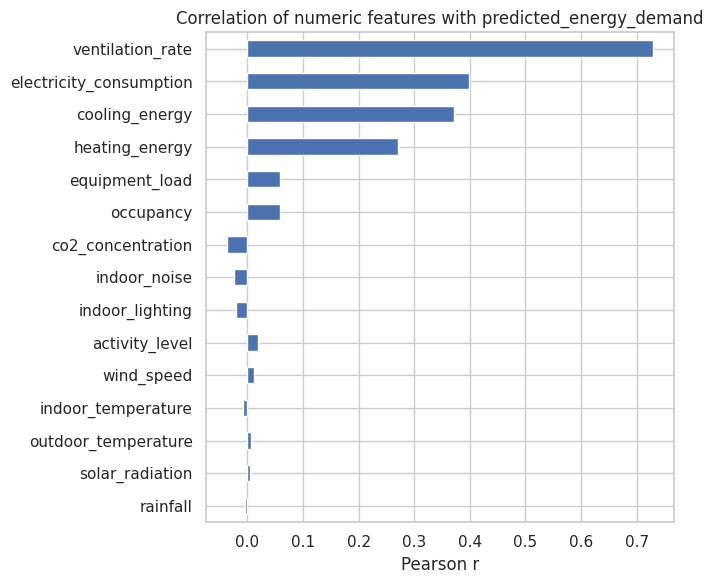

In [17]:
# Correlation of each candidate with the target
corr_t = (num.corr()[target_col].drop(target_col)
          .sort_values(key=np.abs, ascending=False))
print(corr_t)

plt.figure(figsize=(7, max(3, 0.4*len(corr_t))))
corr_t.iloc[::-1].plot(kind="barh")
plt.title(f"Correlation of numeric features with {target_col}")
plt.xlabel("Pearson r"); plt.tight_layout(); plt.show()


Feature selection: correlation filter → VIF pruning

In [18]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Step 1 — correlation filter
threshold = 0.10
candidates = corr_t[np.abs(corr_t) >= threshold].index.tolist()
if len(candidates) < 2:                       # safety fallback
    candidates = corr_t.index[:6].tolist()
print("After correlation filter:", candidates)

# Step 2 — greedily drop the highest-VIF feature until all VIF <= 10
def vif_prune(cols, data, vif_max=10.0):
    cols = list(cols)
    while len(cols) > 1:
        M = sm.add_constant(data[cols].values)
        vifs = [variance_inflation_factor(M, i+1) for i in range(len(cols))]
        worst = int(np.argmax(vifs))
        if vifs[worst] > vif_max:
            print(f"  drop '{cols[worst]}' (VIF={vifs[worst]:.1f})")
            cols.pop(worst)
        else:
            break
    return cols

selected = vif_prune(candidates, num)
print("\nSelected features:", selected)

After correlation filter: ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']

Selected features: ['ventilation_rate', 'electricity_consumption', 'cooling_energy', 'heating_energy']


In [19]:
# OLS with full inferential summary (p-values, R^2, F-test)
Xo = sm.add_constant(num[selected])
ols = sm.OLS(num[target_col], Xo).fit()
print(ols.summary())

                               OLS Regression Results                              
Dep. Variable:     predicted_energy_demand   R-squared:                       0.942
Model:                                 OLS   Adj. R-squared:                  0.942
Method:                      Least Squares   F-statistic:                     9663.
Date:                     Mon, 15 Jun 2026   Prob (F-statistic):               0.00
Time:                             14:31:05   Log-Likelihood:                -5413.7
No. Observations:                     2400   AIC:                         1.084e+04
Df Residuals:                         2395   BIC:                         1.087e+04
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [20]:
# Out-of-sample evaluation with a clean train/test split
Xf = num[selected].values
yf = num[target_col].values
Xtr, Xte, ytr, yte = train_test_split(Xf, yf, test_size=0.2, random_state=RANDOM_STATE)

sc = StandardScaler().fit(Xtr)
lr = LinearRegression().fit(sc.transform(Xtr), ytr)
pred = lr.predict(sc.transform(Xte))

r2 = r2_score(yte, pred)
n, p = Xte.shape
adj = 1 - (1 - r2) * (n - 1) / (n - p - 1)
rmse = np.sqrt(mean_squared_error(yte, pred))
mae = np.mean(np.abs(yte - pred))
print(f"Test  R^2={r2:.4f}   Adj R^2={adj:.4f}   RMSE={rmse:.3f}   MAE={mae:.3f}")

# Standardised coefficients => comparable effect sizes
coef = pd.Series(lr.coef_, index=selected).sort_values(key=np.abs, ascending=False)
print("\nStandardised coefficients (effect size on energy demand):\n", coef)

Test  R^2=0.9491   Adj R^2=0.9486   RMSE=2.181   MAE=1.717

Standardised coefficients (effect size on energy demand):
 ventilation_rate           7.141264
electricity_consumption    4.171551
cooling_energy             3.554806
heating_energy             2.832768
dtype: float64


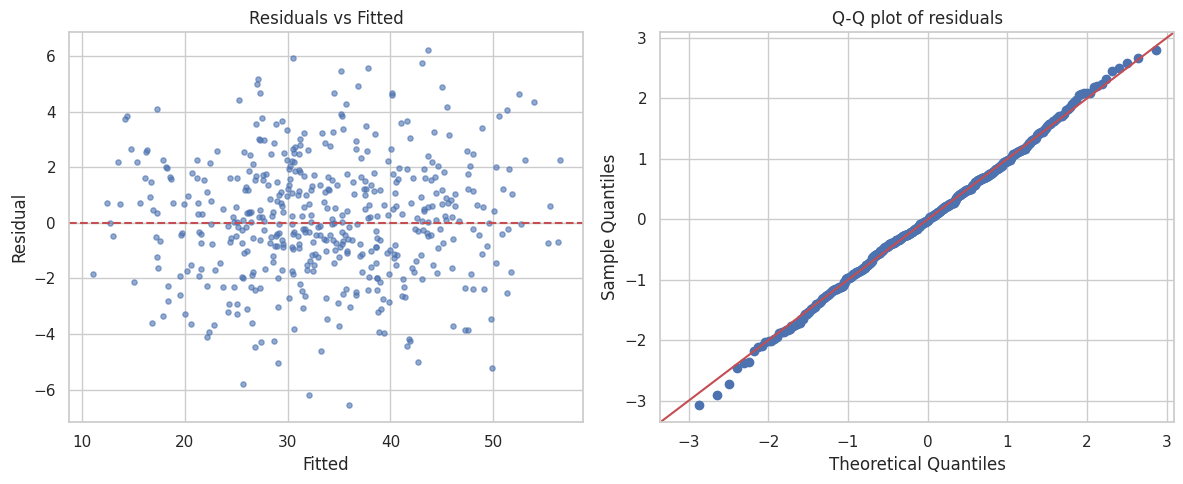

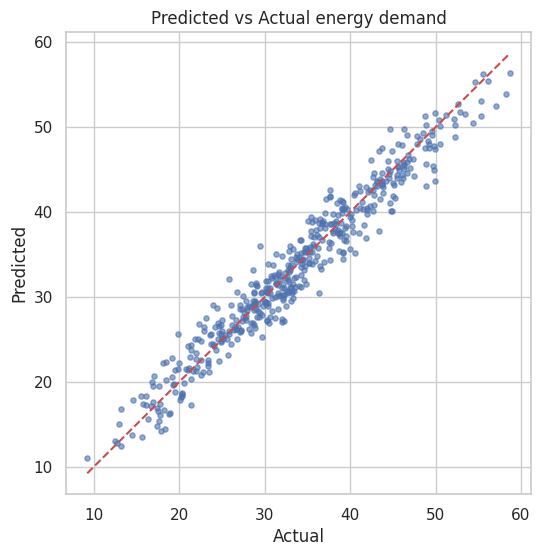

In [21]:
# Residual diagnostics — are the linear-model assumptions reasonable?
resid = yte - pred
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(pred, resid, s=14, alpha=0.6); ax[0].axhline(0, color="r", ls="--")
ax[0].set_xlabel("Fitted"); ax[0].set_ylabel("Residual")
ax[0].set_title("Residuals vs Fitted")
sm.qqplot(resid, line="45", fit=True, ax=ax[1])
ax[1].set_title("Q-Q plot of residuals")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(yte, pred, s=14, alpha=0.6)
lo, hi = yte.min(), yte.max(); plt.plot([lo, hi], [lo, hi], "r--")
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Predicted vs Actual energy demand"); plt.show()

### Discussion & conclusion — Part 2

**How to read the output.**
- **Parameter justification.** Each retained feature passed two gates: a meaningful linear correlation with the target *and* survival of VIF pruning (so the kept predictors are not redundant copies of one another). The OLS `summary()` confirms which coefficients are statistically significant (p < 0.05); any non-significant survivor can be dropped for an even leaner model.
- **Goodness of fit.** Read `Adj R²` (penalises extra predictors) and `RMSE`/`MAE` (error in the target's own units). Test-set metrics close to the training `R²` indicate the linear model generalises rather than overfits.
- **Effect sizes.** Because features were standardised before fitting `LinearRegression`, the coefficients are directly comparable — the largest-magnitude ones are the strongest linear drivers of energy demand.
- **Assumption check.** A residuals-vs-fitted plot with no funnel/curve supports linearity + homoscedasticity; a roughly straight Q-Q plot supports normal residuals. **Curvature or a funnel** is the signal that a purely linear relationship is insufficient and that interaction terms, a log/Box-Cox transform of the target, or a non-linear model would do better.

**Conclusion.** A linear model built from correlation- and VIF-screened parameters gives an interpretable, defensible first model for `predicted_energy_demand`. If `Adj R²` is high and the residual diagnostics are clean, the linear assumption is adequate and the selected parameters are sufficient. If `R²` is modest or the residuals show structure, that itself is the finding — energy demand depends non-linearly (or interactively) on the environment variables, and the linear model is best treated as a baseline.
